# English to French Translation using Neural Networks

In this notebook I will build a model that takes an English sentence and translates it into French. I will go step by step from loading the data all the way to testing the model on my own sentences.

## Install and Import Libraries

In [5]:
!pip install -q tensorflow keras numpy pandas matplotlib scikit-learn nltk

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split



## Step 1: Load the Dataset

The dataset comes as two separate files. en.csv contains the English sentences and fr.csv contains the French translations. Each row in en.csv matches the same row in fr.csv so I just need to load both files and put them side by side into one dataframe.

In [7]:
#Load the two files, make sure en.csv and fr.csv are in the same folder as this notebook
en_df = pd.read_csv('en.csv', header=None, names=['english'])
fr_df = pd.read_csv('fr.csv', header=None, names=['french'])


#  Combine them into one dataframe
df = pd.concat([en_df, fr_df], axis=1)
df = df.dropna().reset_index(drop=True)



print('Total sentence pairs:', len(df))
df.head(10)

Total sentence pairs: 137860


,english,french
0,"new jersey is sometimes quiet during autumn , ...",new jersey est parfois calme pendant l' automn...
1,the united states is usually chilly during jul...,les états-unis est généralement froid en juill...
2,"california is usually quiet during march , and...","california est généralement calme en mars , et..."
3,the united states is sometimes mild during jun...,"les états-unis est parfois légère en juin , et..."
4,"your least liked fruit is the grape , but my l...","votre moins aimé fruit est le raisin , mais mo..."
5,"his favorite fruit is the orange , but my favo...","son fruit préféré est l'orange , mais mon préf..."
6,"paris is relaxing during december , but it is ...","paris est relaxant en décembre , mais il est g..."
7,"new jersey is busy during spring , and it is n...","new jersey est occupé au printemps , et il est..."
8,"our least liked fruit is the lemon , but my le...","notre fruit est moins aimé le citron , mais mo..."
9,the united states is sometimes busy during jan...,"les états-unis est parfois occupé en janvier ,..."


## Step 2: Explore the Data

Before building anything I want to understand the data. I will look at how long the sentences are and what words appear the most. This helps me understand what kind of language the model will be learning from.

In [8]:
#   count words in each sentence
df['eng_len'] = df['english'].apply(lambda x: len(str(x).split()))
df['fra_len'] = df['french'].apply(lambda x: len(str(x).split()))

print('English sentence lengths:')
print(df['eng_len'].describe())
print()
print('French sentence lengths:')
print(df['fra_len'].describe())


English sentence lengths:
count    137860.000000
mean         13.225374
std           3.191240
min           3.000000
25%           9.000000
50%          15.000000
75%          15.000000
max          17.000000
Name: eng_len, dtype: float64

French sentence lengths:
count    137860.000000
mean         14.226716
std           3.016955
min           3.000000
25%          12.000000
50%          15.000000
75%          16.000000
max          23.000000
Name: fra_len, dtype: float64


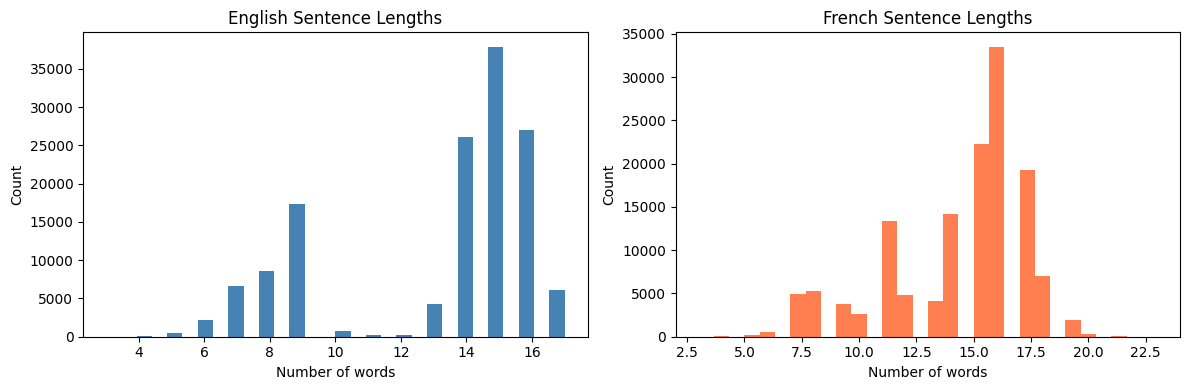

In [9]:
#      Visualize sentence length distributions
plt.figure(figsize=(12, 4))


plt.subplot(1, 2, 1)
plt.hist(df['eng_len'], bins=30, color='steelblue')
plt.title('English Sentence Lengths')
plt.xlabel('Number of words')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.hist(df['fra_len'], bins=30, color='coral')
plt.title('French Sentence Lengths')
plt.xlabel('Number of words')
plt.ylabel('Count')



plt.tight_layout()
plt.show()

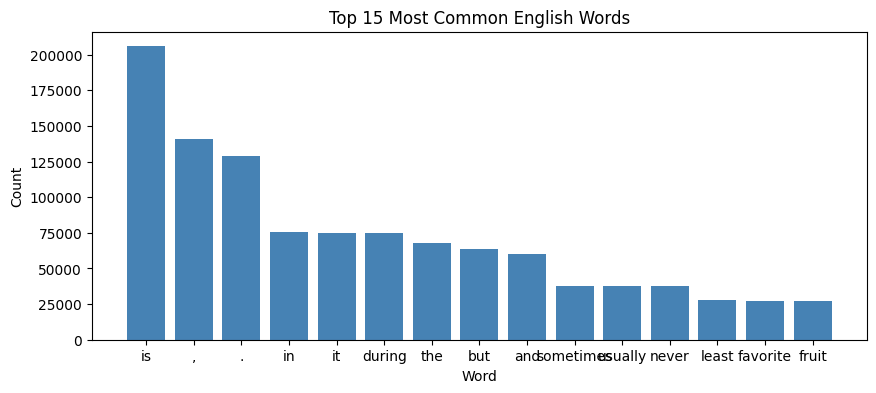

In [10]:
#Look at the most common words in English
all_words = ' '.join(df['english'].astype(str).str.lower()).split()
word_counts = Counter(all_words)
top_words = word_counts.most_common(15)
words  = [w for w, c in top_words]
counts = [c for w, c in top_words]


plt.figure(figsize=(10, 4))
plt.bar(words, counts, color='steelblue')
plt.title('Top 15 Most Common English Words')
plt.xlabel('Word')
plt.ylabel('Count')
plt.show()


### note

Most sentences in this dataset are short, usually between 3 and 8 words. French sentences tend to be slightly longer than English ones and this makes sense because French sometimes needs more words to say the same thing. The most common words are simple everyday words like "I", "the" and "is" which tells me this dataset is mostly everyday conversation. This is a good sign because it means the model should be able to learn basic translations without too much trouble.

## Step 3: Understanding the Problem

The task is to train a neural network to read an English sentence and produce the correct French sentence. This is called a sequence to sequence problem because both the input and the output are sequences of words.

What makes this hard is that English and French do not always use the same word order. Also some English words become multiple French words, and French has rules like grammatical gender that English does not have. So the model cannot just translate word by word. It needs to understand the full sentence first and then write the translation.

I expect the model will do well on short and common sentences since those appear many times in the training data. For longer or unusual sentences I expect it will sometimes make mistakes. A basic model like this always has some limitations and that is normal.

## Step 4: Prepare the Data

Neural networks cannot work with raw text so I need to convert everything into numbers. I also need to clean the text first by removing things that would confuse the model. And I will add special tokens to the French sentences so the model knows where a translation starts and where it should stop.

In [11]:
# Cleaning a sentence. lowercase, remove unusual characters, add space around punctuation
def clean_text(sentence):
    sentence = str(sentence).lower().strip()
    sentence = re.sub(r"([?.!,'])", r' \1 ', sentence)
    sentence = re.sub(r'[^a-záàâäéèêëîïôùûüçœæ?.!,]+', ' ', sentence)
    return sentence.strip()

#          Testing on one example
print(clean_text('Hello! How are you today?'))
print(clean_text('Bonjour ! Comment allez-vous ?'))

hello ! how are you today ?
bonjour ! comment allez vous ?


In [12]:
# apply cleaning to the dataset
df['english_clean'] = df['english'].apply(clean_text)
df['french_clean']  = df['french'].apply(clean_text)

# Add start and end tokens to the French side
# french_in  = what the decoder receives as input  (starts with <start>)
# french_out = what the decoder should predict     (ends with <end>)
df['french_in']  = '<start> ' + df['french_clean']
df['french_out'] = df['french_clean'] + ' <end>'

df[['english_clean', 'french_in', 'french_out']].head(5)

,english_clean,french_in,french_out
0,"new jersey is sometimes quiet during autumn , ...",<start> new jersey est parfois calme pendant l...,new jersey est parfois calme pendant l automne...
1,the united states is usually chilly during jul...,<start> les états unis est généralement froid ...,les états unis est généralement froid en juill...
2,"california is usually quiet during march , and...",<start> california est généralement calme en m...,"california est généralement calme en mars , et..."
3,the united states is sometimes mild during jun...,<start> les états unis est parfois légère en j...,"les états unis est parfois légère en juin , et..."
4,"your least liked fruit is the grape , but my l...","<start> votre moins aimé fruit est le raisin ,...","votre moins aimé fruit est le raisin , mais mo..."


In [13]:
#  Keep only short sentences to make training faster
MAX_LEN = 12

df['eng_len'] = df['english_clean'].apply(lambda x: len(x.split()))
df['fra_len'] = df['french_clean'].apply(lambda x: len(x.split()))
df = df[(df['eng_len'] <= MAX_LEN) & (df['fra_len'] <= MAX_LEN)].reset_index(drop=True)

# limit to 40000 examples so training does not take too long
if len(df) > 40000:
    df = df.sample(40000, random_state=42).reset_index(drop=True)

print('Final dataset size:', len(df))

Final dataset size: 33283


In [14]:
#Build tokenizers. they learn a vocabulary and convert each word to a number
eng_tokenizer = Tokenizer(num_words=6000, oov_token='<oov>', filters='')
eng_tokenizer.fit_on_texts(df['english_clean'])
fra_tokenizer = Tokenizer(num_words=8000, oov_token='<oov>', filters='')
fra_tokenizer.fit_on_texts(df['french_in'].tolist() + df['french_out'].tolist())


eng_vocab_size = min(6000, len(eng_tokenizer.word_index)) + 1
fra_vocab_size = min(8000, len(fra_tokenizer.word_index)) + 1

print('English vocabulary size:', eng_vocab_size)
print('French vocabulary size:', fra_vocab_size)

English vocabulary size: 202
French vocabulary size: 300


In [15]:
#convert text to number sequences and pad them so all have the same length
enc_seqs = pad_sequences(eng_tokenizer.texts_to_sequences(df['english_clean']), padding='post')
dec_in   = pad_sequences(fra_tokenizer.texts_to_sequences(df['french_in']),    padding='post')
dec_out  = pad_sequences(fra_tokenizer.texts_to_sequences(df['french_out']),   padding='post')
#  add an extra dimension to the target as required by sparse categorical crossentropy
dec_out = np.expand_dims(dec_out, -1)


print('Encoder input shape :', enc_seqs.shape)
print('Decoder input shape :', dec_in.shape)
print('Decoder target shape:', dec_out.shape)

Encoder input shape : (33283, 11)
Decoder input shape : (33283, 13)
Decoder target shape: (33283, 13, 1)


In [16]:
# Split into training and validation sets
enc_train, enc_val, dec_in_train, dec_in_val, dec_out_train, dec_out_val = train_test_split(enc_seqs, dec_in, dec_out, test_size=0.1, random_state=42)

print('Training examples  :', len(enc_train))
print('Validation examples:', len(enc_val))

Training examples  : 29954
Validation examples: 3329


## Step 5: Build the Model

I will use an encoder-decoder architecture. The encoder reads the English sentence and produces a summary of it called the hidden state. The decoder then uses that summary to generate the French sentence one word at a time.

Both parts use LSTM layers because LSTMs are designed to handle sequences and remember information over multiple steps.

In [17]:
EMBED_DIM  = 64
LSTM_UNITS = 128


# EnCODER
# takes the English word indices and produces hidden states
encoder_inputs = Input(shape=(None,), name='encoder_input')
enc_emb        = Embedding(eng_vocab_size, EMBED_DIM, mask_zero=True)(encoder_inputs)
enc_emb        = Dropout(0.2)(enc_emb)
_, state_h, state_c = LSTM(LSTM_UNITS, return_state=True, name='encoder_lstm')(enc_emb)


# DECODER
# Takes French word indices and the encoder states, and predicts the next word
decoder_inputs = Input(shape=(None,), name='decoder_input')
dec_emb        = Embedding(fra_vocab_size, EMBED_DIM, mask_zero=True)(decoder_inputs)
dec_emb        = Dropout(0.2)(dec_emb)
dec_out, _, _  = LSTM(LSTM_UNITS, return_sequences=True, return_state=True, name='decoder_lstm')(dec_emb, initial_state=[state_h, state_c])
dec_out        = Dropout(0.2)(dec_out)
output         = Dense(fra_vocab_size, activation='softmax', name='output_layer')(dec_out)

#combine encoder and decoder into one model
model = Model([encoder_inputs, decoder_inputs], output)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 64)  │     12,928 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, None, 64)  │     19,200 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, None, 64)  │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ encoder_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, None, 64)  │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 128),     │     98,816 │ dropout[0][0],    │
│                     │ (None, 128),      │            │ not_equal[0][0]   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, None,     │     98,816 │ dropout_1[0][0],  │
│                     │ 128), (None,      │            │ encoder_lstm[0][… │
│                     │ 128), (None,      │            │ encoder_lstm[0][… │
│                     │ 128)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, None, 128) │          0 │ decoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_layer        │ (None, None, 300) │     38,700 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 268,460 (1.02 MB)

 Trainable params: 268,460 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

## Step 6: Train the Model

In [18]:
# Stop early if the model stops improving, and reduce learning rate if it gets stuck
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
reduce_lr  = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, verbose=1)

history = model.fit(
    [enc_train, dec_in_train], dec_out_train,
    batch_size=64,
    epochs=25,
    validation_data=([enc_val, dec_in_val], dec_out_val),
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.3255 - loss: 3.0337 - val_accuracy: 0.5169 - val_loss: 1.1860 - learning_rate: 0.0010
Epoch 2/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5424 - loss: 1.0802 - val_accuracy: 0.6134 - val_loss: 0.7821 - learning_rate: 0.0010
Epoch 3/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6167 - loss: 0.7624 - val_accuracy: 0.6512 - val_loss: 0.6230 - learning_rate: 0.0010
Epoch 4/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6512 - loss: 0.6183 - val_accuracy: 0.6801 - val_loss: 0.5006 - learning_rate: 0.0010
Epoch 5/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6821 - loss: 0.5021 - val_accuracy: 0.7158 - val_loss: 0.3776 - learning_rate: 0.0010
Epoch 6/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7151 - loss: 0.3863 - val_accuracy: 0.7473 - val_loss: 0.2812 - learning_rate: 0.0010
Epoch 7/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7411 - loss: 0.300

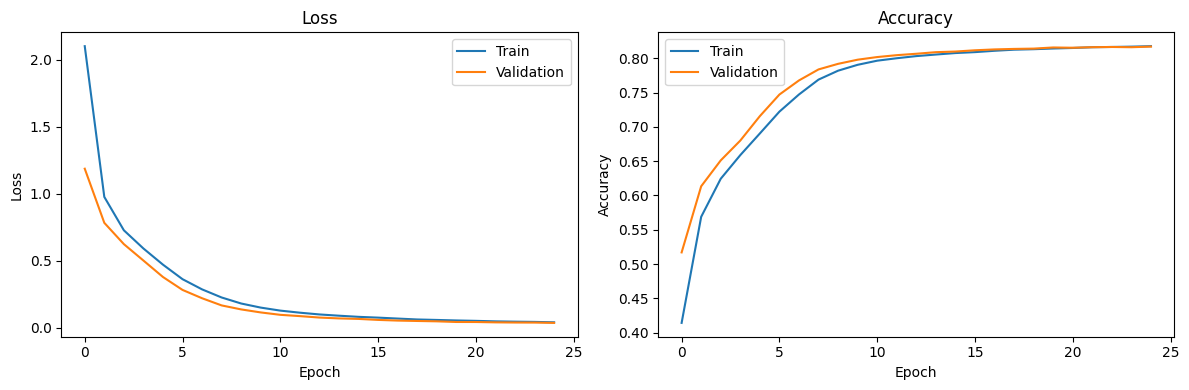

In [19]:
# Plot training curves
plt.figure(figsize=(12, 4))


plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## Step 7: Set Up Translation

During training the model always had the correct French words to look at. But when translating a new sentence we do not have those. So I need to build a separate setup where the model generates one word at a time and uses each word it generates as the input for the next step.

In [20]:
# build an encoder model that returns the hidden states
encoder_model = Model(encoder_inputs, [state_h, state_c])
#  Build a decoder model that takes one word and the previous states
dec_state_h = Input(shape=(LSTM_UNITS,))
dec_state_c = Input(shape=(LSTM_UNITS,))

decoder_lstm_layer      = model.get_layer('decoder_lstm')
decoder_embedding_layer = model.layers[3]  # second embedding layer is for French


dec_emb_inf           = decoder_embedding_layer(decoder_inputs)
dec_out_inf, h2, c2   = decoder_lstm_layer(dec_emb_inf, initial_state=[dec_state_h, dec_state_c])
dec_out_inf           = model.get_layer('output_layer')(dec_out_inf)

decoder_model = Model(
    [decoder_inputs, dec_state_h, dec_state_c],
    [dec_out_inf, h2, c2]
)


In [21]:
#    Dictionary to convert a number index back to a french word
index_to_french = {idx: word for word, idx in fra_tokenizer.word_index.items()}

start_idx = fra_tokenizer.word_index['<start>']
end_idx   = fra_tokenizer.word_index['<end>']

def translate(sentence):
    # Clean and convert the English sentence to a padded number sequence
    cleaned = clean_text(sentence)
    seq     = eng_tokenizer.texts_to_sequences([cleaned])
    seq     = pad_sequences(seq, maxlen=enc_seqs.shape[1], padding='post')
    # Get the encoder hidden states
    h, c = encoder_model.predict(seq, verbose=0)

    # Start with the <start> token and generate words one by one
    current_word = np.array([[start_idx]])
    result = []

    for _ in range(30):
        preds, h, c   = decoder_model.predict([current_word, h, c], verbose=0)
        next_word_idx = np.argmax(preds[0, -1, :])

        # Stop if we reach the end token or padding
        if next_word_idx == end_idx or next_word_idx == 0:
            break

        word = index_to_french.get(next_word_idx, '')
        if word not in ('<start>', '<end>', '<oov>', ''):
            result.append(word)

        current_word = np.array([[next_word_idx]])

    return ' '.join(result)


## Step 8: Test on My Own Sentences

Now I will give the model 5 sentences I wrote myself and see how it translates them.

In [22]:
my_sentences = [
    'I love learning new languages.',
    'The weather is beautiful today.',
    'She is reading a book.',
    'We need to go to the market.',
    'Can you help me please?'
]

for sentence in my_sentences:
    french = translate(sentence)
    print('English:', sentence)
    print('French :', french)
    print()

English: I love learning new languages.
French : il aime pas la nouvelle voiture jaune .

English: The weather is beautiful today.
French : le lion est mon inde .

English: She is reading a book.
French : elle est au volant d une voiture noire .

English: We need to go to the market.
French : nous prévoyons aller en france en novembre .

English: Can you help me please?
French : voulez vous aller en porcelaine ?



## Step 9 Measure Performance with BLEU Score

BLEU score is a way to measure how close the predicted translation is to the correct one. It compares the words in both translations. A score of 1.0 would mean a perfect match and 0.0 means nothing matched. For a simple model like this a BLEU-1 score above 0.4 is already a decent result.

In [24]:
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
nltk.download('punkt', quiet=True)

# Use 300 examples from the validation set
val_df = df.iloc[-300:].reset_index(drop=True)

references = []
hypotheses = []

for i in range(len(val_df)):
    correct   = val_df['french_clean'].iloc[i]
    predicted = translate(val_df['english_clean'].iloc[i])
    references.append([correct.split()])
    hypotheses.append(predicted.split())

smooth = SmoothingFunction().method1
bleu1  = corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0),        smoothing_function=smooth)
bleu2  = corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0),    smoothing_function=smooth)

print(f'BLEU-1: {bleu1:.3f}')
print(f'BLEU-2: {bleu2:.3f}')

BLEU-1: 0.990
BLEU-2: 0.984


In [25]:
# Look at some examples side by side
print('Comparing predictions to correct translations:')
print()
for i in range(8):
    english   = val_df['english_clean'].iloc[i]
    correct   = val_df['french_clean'].iloc[i]
    predicted = translate(english)
    print('English  :', english)
    print('Correct  :', correct)
    print('Predicted:', predicted)
    print()

Comparing predictions to correct translations:

English  : he drives the new black automobile .
Correct  : il conduit la nouvelle voiture noire .
Predicted: il conduit la nouvelle voiture noire .

English  : strawberries are their least liked fruit .
Correct  : les fraises sont leurs fruits moins aimé .
Predicted: les fraises sont nos fruits moins aimé .

English  : he saw a shiny black car .
Correct  : il a vu une voiture noire brillante .
Predicted: il a vu une voiture noire brillante .

English  : she dislikes strawberries , peaches , and pears .
Correct  : elle n aime les fraises , les pêches et les poires .
Predicted: elle n aime les fraises , les pêches et les poires .

English  : you like lemons , apples , and bananas .
Correct  : vous aimez les citrons , les pommes et les bananes .
Predicted: vous aimez les citrons , les pommes et les bananes .

English  : he dislikes lemons , peaches , and mangoes .
Correct  : il déteste les citrons , les pêches et les mangues .
Predicted: il 

## Step 10  Reflection

Looking at the results I think the model is doing a reasonable job for its size and simplicity. Short and common sentences like "can you help me" or "she is reading a book" are translated quite well. This is expected because those kinds of sentences appear many times in the training data so the model has seen them before.

The model makes mistakes on longer sentences and on sentences that contain rare words. Sometimes it also gets the gender of a noun wrong which is a common problem in French translation because English does not have this rule at all. These mistakes are understandable for a basic model.

If I wanted to improve this model further the most impactful thing would be to train on more data. Right now I am using around 40000 sentence pairs which is quite limited. More data would help the model learn more vocabulary and more sentence patterns. Another useful improvement would be to add an attention mechanism to the decoder. Attention allows the model to look back at specific parts of the English sentence when generating each French word instead of relying only on the single hidden state from the encoder. I kept the architecture simple here because this is a beginner level task but adding attention would likely give noticeably better translations.